In [1]:
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
import math


In [2]:
from datasets import load_dataset
from transformers import AutoTokenizer
import torch
from torch.utils.data import DataLoader

# 1. Load dataset and tokenizer
ds = load_dataset("JeanKaddour/minipile", split="train[:10%]") # Using 1% for speed
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

def tokenize_function(examples,prt = 'text'):
    return tokenizer(examples[prt], truncation=True, padding="max_length", max_length=128)

tokenized_ds = ds.map(tokenize_function, batched=True, remove_columns=["text"])
tokenized_ds.set_format("torch")

train_loader = DataLoader(tokenized_ds, batch_size=8, shuffle=True)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00012-6fbcb5acda05b3(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

data/train-00001-of-00012-2bb9d088068a84(…):   0%|          | 0.00/262M [00:00<?, ?B/s]

data/train-00002-of-00012-efb6c8de042720(…):   0%|          | 0.00/259M [00:00<?, ?B/s]

data/train-00003-of-00012-47006e5a888a93(…):   0%|          | 0.00/275M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

In [3]:
class FF(nn.Module):
  def __init__(self,dim):
    super().__init__()
    self.dim = dim
    self.linear1 = nn.Linear(dim,dim)
    self.relu = nn.ReLU()
    self.linear2 = nn.Linear(dim,dim)
  def forward(self,x):
    x = self.linear1(x)
    x = self.relu(x)
    x = self.linear2(x)
    return x

class transformer_block(nn.Module):
  def __init__(self,dim,num_heads=4):
    super().__init__()

    self.dim = dim
    self.FF = FF(dim)
    self.mmAt = nn.MultiheadAttention(dim, num_heads, batch_first=True)
    self.norm1 = nn.LayerNorm(dim)
    self.norm2 = nn.LayerNorm(dim)

  def forward(self,x,attention_mask):
    # layer_norm = nn.LayerNorm(embedding_dim)

    attn_out, _ = self.mmAt(x, x, x,key_padding_mask=~attention_mask,need_weights=False)
    x_mm = attn_out + x
    x_norm1 = self.norm1(x_mm)
    x_ff = self.FF(x_norm1)
    x_norm2 = self.norm2(x_ff + x_norm1)
    # TODO: add drop out
    return x_norm2

class transformer(nn.Module):
  def __init__(self, vocab_size, dim, num_layers=6):
          super().__init__()
          self.positionalencoding = LearnedPositionalEncoding(max_seq_len=vocab_size, dim=dim)
          self.embedding = nn.Embedding(vocab_size, dim)

          self.layers = nn.ModuleList([
              transformer_block(dim) for _ in range(num_layers)
          ])

          self.to_logits = nn.Linear(dim, vocab_size)

  def forward(self, x,attention_mask):

      x = self.embedding(x)
      #print(np.shape(x))
      #print(x)
      x = self.positionalencoding(x)

      for layer in self.layers:
          x = layer(x,attention_mask)

      return self.to_logits(x)



class LearnedPositionalEncoding(nn.Module):
    def __init__(self, max_seq_len, dim):
        super().__init__()
        self.position_embeddings = nn.Embedding(max_seq_len, dim)
        
    def forward(self, x):
        positions = torch.arange(x.size(1), device=x.device).expand(x.size(0), -1)
        position_embeddings = self.position_embeddings(positions)
        #print(np.shape(x))
        #print(np.shape(position_embeddings))
        return x + position_embeddings



# Language pre training

In [4]:
import torch.optim as optim
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vocab_size = tokenizer.vocab_size
dim = 256
e = 10

model = transformer(vocab_size, dim,num_layers=6).to(device)
optimizer = optim.AdamW(model.parameters(), lr=5e-4)
criterion = nn.CrossEntropyLoss()
loss_list = []
model.train()
for epoch in range(e):
    total_loss = 0
    for batch in tqdm(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device).bool()  # bool is recommended

        logits = model(input_ids,attention_mask)


        shift_logits = logits[:, :-1, :].contiguous().view(-1, vocab_size)
        shift_labels = input_ids[:, 1:].contiguous().view(-1)

        loss = criterion(shift_logits, shift_labels)

        # 3. Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_list.append(loss.item())
        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Average Loss: {total_loss/len(train_loader):.4f}")

100%|██████████| 12500/12500 [12:14<00:00, 17.01it/s]


Epoch 1 | Average Loss: 0.5004


100%|██████████| 12500/12500 [12:19<00:00, 16.90it/s]


Epoch 2 | Average Loss: 0.0041


100%|██████████| 12500/12500 [12:17<00:00, 16.94it/s]


...

Epoch 8 | Average Loss: 0.0078


100%|██████████| 12500/12500 [12:16<00:00, 16.96it/s]


Epoch 9 | Average Loss: 0.0040


100%|██████████| 12500/12500 [12:17<00:00, 16.94it/s]

Epoch 10 | Average Loss: 0.0111


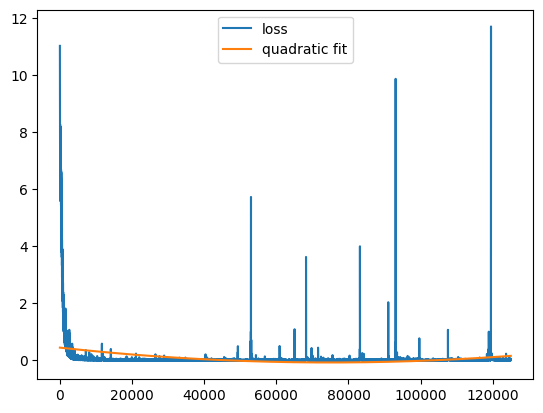

In [5]:
import matplotlib.pyplot as plt
loss = np.array(loss_list)
x = np.arange(len(loss))

# quadratic fit
coeffs = np.polyfit(x, loss, 2)  # degree-2 polynomial
fit_curve = np.polyval(coeffs, x)

plt.plot(loss, label="loss")
plt.plot(fit_curve, label="quadratic fit")
plt.legend()
plt.show()

PATH = 'diffuser'
torch.save(model.state_dict(), PATH)

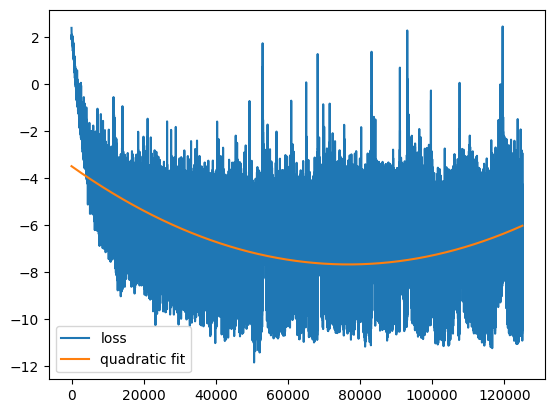

In [6]:

loss = np.array(loss_list)
loss = np.log(loss)

x = np.arange(len(loss))

# quadratic fit
coeffs = np.polyfit(x, loss, 2)  # degree-2 polynomial
fit_curve = np.polyval(coeffs, x)

plt.plot(loss, label="loss")
plt.plot(fit_curve, label="quadratic fit")
plt.legend()
plt.show()

PATH = 'diffuser'
torch.save(model.state_dict(), PATH)

In [7]:
torch.save(model.state_dict(), "pretrained_lm.pt")

In [8]:
import torch

max_id_found = 0
for batch in train_loader:
    max_id_found = max(max_id_found, batch['input_ids'].max().item())

print(f"Max token ID in dataset : {max_id_found}")
print(f"Model vocab size        : {vocab_size}")
print(f"Tokenizer pad token id  : {tokenizer.pad_token_id}")
print(f"Tokenizer eos token id  : {tokenizer.eos_token_id}")

Max token ID in dataset : 50256
Model vocab size        : 50257
Tokenizer pad token id  : 50256
Tokenizer eos token id  : 50256


In [9]:
# Check your max sequence length in the data vs your model's limit
max_len_found = max(batch['input_ids'].shape[1] for batch in train_loader)
print(f"Max sequence length in data : {max_len_found}")
print(f"Model max_seq_len            : {model.embedding}")  # whatever you named it

Max sequence length in data : 128
Model max_seq_len            : Embedding(50257, 256)


In [10]:
def generate(model, tokenizer, prompt, max_new_tokens=50, temperature=0.8, top_k=1, device="cuda"):
    model.eval()
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            # Create attention mask (all 1s for generated sequence)
            attention_mask = torch.ones_like(input_ids, dtype=torch.bool).to(device)

            # Forward pass
            logits = model(input_ids, attention_mask)

            # Get logits for the last token only
            next_token_logits = logits[:, -1, :] / temperature

            # Top-k filtering
            if top_k > 0:
                indices_to_remove = next_token_logits < torch.topk(next_token_logits, top_k)[0][..., -1, None]
                next_token_logits[indices_to_remove] = float('-inf')

            # Sample from distribution
            probs = torch.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)

            # Append to sequence
            input_ids = torch.cat([input_ids, next_token], dim=1)

            # Stop if EOS token
            if next_token.item() == tokenizer.eos_token_id:
                break

    return tokenizer.decode(input_ids[0], skip_special_tokens=True)


# Usage
prompt = "I am"
output = generate(model, tokenizer, prompt, max_new_tokens=10, temperature=0.1)
print(output)

I am


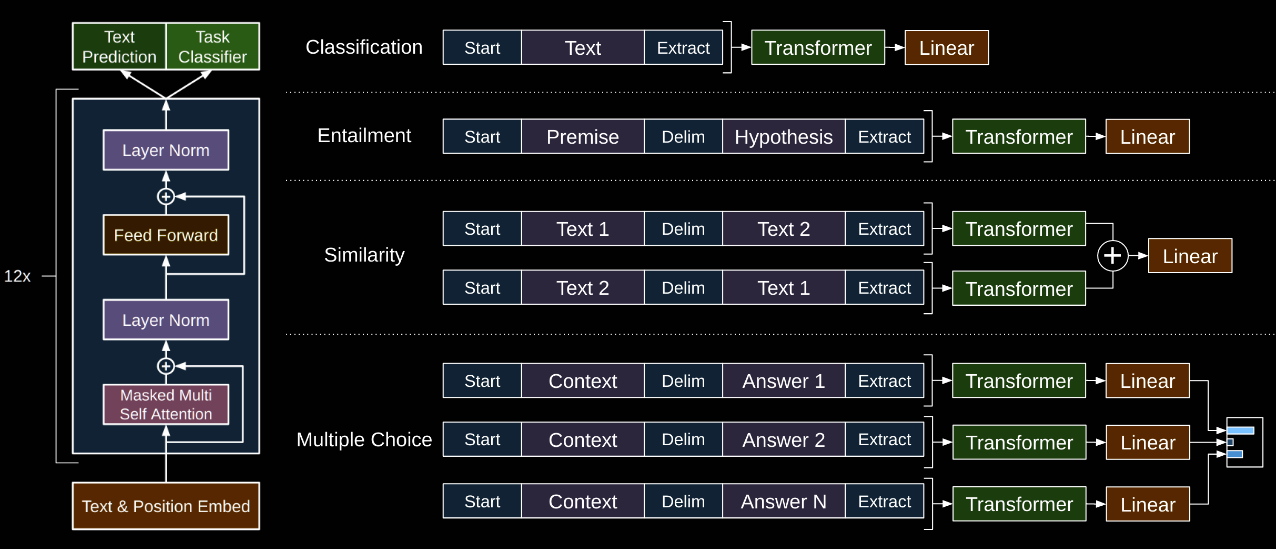

# Task specefic training (spam classification)

In [11]:
from datasets import load_dataset

SMS = load_dataset("ucirvine/sms_spam", split="train[:95%]")
#SMS_test = load_dataset("ucirvine/sms_spam", split="train[:25%]")

def tokenize_function(examples,prt = 'sms'):
    return tokenizer(examples[prt], truncation=True, padding="max_length", max_length=128)

tokenized_SMS = SMS.map(tokenize_function, batched=True, remove_columns=["sms"])
tokenized_SMS.set_format("torch")

#tokenized_SMS_test = SMS_test.map(tokenize_function, batched=True, remove_columns=["sms"])
#tokenized_SMS_test = SMS_test.map(tokenize_function, batched=True, remove_columns=["sms"])


SMS_train_loader = DataLoader(tokenized_SMS, batch_size=8, shuffle=True)
#SMS_test_loader = DataLoader(tokenized_SMS_test, batch_size=8, shuffle=True)


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/359k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5574 [00:00<?, ? examples/s]

Map:   0%|          | 0/5295 [00:00<?, ? examples/s]

In [12]:
tokenized_SMS['label']

Column([tensor(0), tensor(0), tensor(1), tensor(0), tensor(0)])

In [13]:
class transformer_classifier(nn.Module):
  def __init__(self, vocab_size, dim, num_layers=6,numer_class=1):
          super().__init__()
          self.embedding = nn.Embedding(vocab_size, dim)
          self.positionalencoding = LearnedPositionalEncoding(max_seq_len=vocab_size, dim=dim)

          self.layers = nn.ModuleList([
              transformer_block(dim) for _ in range(num_layers)
          ])

          self.classifier = nn.Linear(dim, numer_class)
          self.tahn = nn.Tanh()
  def forward(self, x,attention_mask):
      x = self.embedding(x)
      x = self.positionalencoding(x)

      for layer in self.layers:
          x = layer(x,~attention_mask)
      cls_repr = x[:, 0, :] 
      return self.classifier(x)




In [14]:
for batch in tqdm(SMS_train_loader):
    input_ids = batch['input_ids'].to(device)
    print(np.shape(input_ids))
    break

  0%|          | 0/662 [00:00<?, ?it/s]

torch.Size([8, 128])


In [15]:
import torch.optim as optim
from tqdm import tqdm


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vocab_size = tokenizer.vocab_size
dim = 256
e = 10

classifier = transformer_classifier(vocab_size,dim,numer_class=1).to(device)
pretrained_weights = torch.load("pretrained_lm.pt")

pretrained_weights = {k: v for k, v in pretrained_weights.items() 
                      if not k.startswith("to_logits")}

classifier.load_state_dict(pretrained_weights, strict=False)

optimizer = optim.SGD(classifier.parameters(), lr=0.001, momentum=0.9)

criterion = nn.BCEWithLogitsLoss()

classifier.train()
for epoch in range(e):
    total_loss = 0
    for batch in tqdm(SMS_train_loader):
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device).bool()
        labels = batch['label'].to(device)
        #print(input_ids)
        logits = classifier(input_ids,attention_mask).squeeze(-1)
        logits = logits[:, 0] 
        #print(logits)
        loss = criterion(logits, labels.float())


        # 3. Backward pass
        torch.nn.utils.clip_grad_norm_(classifier.parameters(), max_norm=1.0)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Average Loss: {total_loss/len(train_loader):.4f}")

100%|██████████| 662/662 [00:13<00:00, 50.45it/s]


Epoch 1 | Average Loss: 0.0362


100%|██████████| 662/662 [00:12<00:00, 51.05it/s]


Epoch 2 | Average Loss: 0.0289


100%|██████████| 662/662 [00:12<00:00, 51.23it/s]


...

Epoch 8 | Average Loss: 0.0127


100%|██████████| 662/662 [00:12<00:00, 51.43it/s]


Epoch 9 | Average Loss: 0.0117


100%|██████████| 662/662 [00:12<00:00, 51.54it/s]

Epoch 10 | Average Loss: 0.0112


In [16]:
def classify(model, tokenizer, prompt, device="cuda"):
    model.eval()
    inputs = tokenizer(prompt, truncation=True, padding="max_length", max_length=128,return_tensors="pt").to(device)
    #print(inputs)
    with torch.no_grad():

        input_ids = torch.tensor(inputs['input_ids']).to(device)
        #print(np.shape(input_ids))
        attention_mask = torch.tensor(inputs['attention_mask']).to(device).bool()
        logits = model(input_ids, attention_mask).squeeze(-1)
        print(logits)
        logits = logits[:, 0] 
        print(logits)

    return int(logits > 0)
    #return logits



In [17]:

# Usage
prompt = "Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
output = classify(classifier, tokenizer, prompt )
print(output)

/tmp/ipykernel_55/2757802414.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids = torch.tensor(inputs['input_ids']).to(device)
/tmp/ipykernel_55/2757802414.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  attention_mask = torch.tensor(inputs['attention_mask']).to(device).bool()


tensor([[-2.1806e+00, -2.4848e+00, -2.6272e-01, -2.3521e+00, -1.2833e+00,
         -2.1007e+00, -1.8759e+00, -1.7123e+00, -1.5337e+00, -2.0686e+00,
         -1.6530e+00, -1.3204e+00, -1.9113e+00, -1.8780e+00, -1.7000e+00,
         -1.7438e+00, -1.5207e+00, -2.5419e+00, -1.4793e+00, -1.1492e+00,
         -2.8562e-01, -2.1214e+00, -2.5879e+00, -2.5422e+00, -1.7209e+00,
         -2.0080e+00, -3.1747e+00, -6.4290e-01, -3.5896e-01,  1.8450e+00,
         -5.4742e-02, -4.1869e-01,  1.5751e-01,  7.0490e-01, -1.0241e-01,
          1.5404e+00,  6.2634e-01, -7.8069e-01,  4.8464e-01,  2.6575e+00,
         -2.8433e-01,  3.5723e+00,  1.1689e+00,  3.5536e-01,  1.2088e+00,
         -1.2635e-01,  1.2756e+00,  2.5819e+00,  1.4953e-01, -4.1236e-02,
          5.6349e-01, -1.6972e-01,  2.0396e+00, -1.9313e-02,  1.3002e+00,
         -3.7665e-01,  9.4191e-01, -2.3628e-01,  1.0239e-02,  1.0410e+00,
         -1.0245e+00, -7.6517e-02,  2.3129e+00, -1.6751e-01, -8.8934e-01,
          1.4380e+00,  9.4813e-01, -8.

In [18]:

# Usage
prompt = "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005"
output = classify(classifier, tokenizer, prompt )
print(output)

tensor([[-2.1944, -4.6917, -4.3307, -3.2504, -4.6897, -3.8396, -3.2899, -4.4949,
         -4.5219, -4.1714, -4.9372, -4.6232, -4.9920, -5.2637, -3.9774, -3.8661,
         -4.1990, -4.3631, -4.1026, -2.5079, -3.2381, -1.7978, -2.6259, -2.0811,
         -1.5836, -1.9834, -2.2168, -1.6058, -1.4281, -2.8620, -1.5919, -2.3675,
         -2.3147, -3.5814, -1.9432, -2.3093, -2.9695, -2.2338, -1.6384, -3.3560,
         -2.2489, -2.8400, -1.6152, -1.5268, -2.5906, -2.4235, -4.4028, -2.4699,
         -2.7035, -2.2833, -0.7370, -2.2270, -2.5642, -2.8017, -1.5386, -1.4814,
         -2.2360, -1.7317, -1.5215, -1.9566, -1.6351, -1.1454, -2.0358, -1.0713,
         -1.5324, -1.3992, -1.3970, -1.7426, -1.2654, -1.6357, -1.6939, -1.9228,
         -1.6731, -2.0689, -1.4659, -1.1638, -0.8550, -1.7601, -1.8940, -1.3985,
         -1.7869, -2.0810, -1.6982, -2.8555, -1.8600, -1.7000, -3.5401, -1.6958,
         -1.7873, -1.5731, -2.3058, -1.9943, -1.1105, -1.8834, -1.4592, -2.7883,
         -2.2488, -2.3427, -

/tmp/ipykernel_55/2757802414.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids = torch.tensor(inputs['input_ids']).to(device)
/tmp/ipykernel_55/2757802414.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  attention_mask = torch.tensor(inputs['attention_mask']).to(device).bool()


In [19]:

# Usage
prompt = "Watching telugu movie..wat abt u?"
output = classify(classifier, tokenizer, prompt )
print(output)

tensor([[-4.8425, -4.6122, -2.6544, -3.3981, -4.8233, -4.4915, -4.0821, -4.5836,
         -4.2622, -3.5660, -2.8097, -1.5756, -1.5161, -2.9309, -2.9882, -2.9061,
         -1.8887, -2.2459, -2.6425, -1.4313, -1.3316, -1.8142, -2.6249, -2.0941,
         -1.6004, -1.9943, -2.2253, -1.6245, -1.4284, -2.8743, -1.6067, -2.3763,
         -2.3250, -3.5866, -1.9585, -2.3215, -2.9807, -2.2420, -1.6560, -3.3614,
         -2.2610, -2.8513, -1.6313, -1.5380, -2.6021, -2.3997, -4.4106, -2.5255,
         -2.7158, -2.2966, -0.7538, -2.2412, -2.5795, -2.8151, -1.5499, -1.4950,
         -2.2510, -1.7431, -1.5395, -1.9769, -1.6485, -1.1623, -2.0497, -1.0989,
         -1.5451, -1.4108, -1.5346, -1.7599, -1.2806, -1.6477, -1.7110, -1.9342,
         -1.6866, -2.0839, -1.4804, -1.1787, -0.8690, -1.7709, -1.9081, -1.4445,
         -1.7997, -2.0967, -1.7155, -2.8682, -1.8730, -1.7161, -3.5493, -1.7059,
         -1.7956, -1.5900, -2.3257, -2.0089, -1.1260, -1.8994, -1.4731, -2.8003,
         -2.2655, -2.3610, -

/tmp/ipykernel_55/2757802414.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids = torch.tensor(inputs['input_ids']).to(device)
/tmp/ipykernel_55/2757802414.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  attention_mask = torch.tensor(inputs['attention_mask']).to(device).bool()


In [20]:

# Usage
prompt = "U can call me now..."
output = classify(classifier, tokenizer, prompt )
print(output)

tensor([[-4.8383, -4.9241, -4.0621, -3.5220, -3.8250, -3.1122, -1.5154, -1.7279,
         -1.2308, -1.8845, -2.0969, -1.5895, -1.5292, -2.9496, -3.0100, -2.9271,
         -1.9111, -2.2681, -2.6625, -1.4502, -1.3496, -1.8368, -2.6462, -2.1163,
         -1.6198, -2.0194, -2.2444, -1.6396, -1.4526, -2.8948, -1.5889, -2.3882,
         -2.4054, -3.6044, -1.9824, -2.3407, -2.9991, -2.2524, -1.6780, -3.3772,
         -2.2740, -2.8643, -1.6541, -1.5519, -2.6212, -2.4208, -4.4280, -2.5088,
         -2.7336, -2.3142, -0.7750, -2.2638, -2.5999, -2.8350, -1.5677, -1.5084,
         -2.2735, -1.7571, -1.5640, -1.9997, -1.6657, -1.1876, -2.0713, -1.1229,
         -1.6271, -1.4244, -1.5580, -1.7811, -1.2978, -1.6632, -1.7342, -1.9464,
         -1.7033, -2.0999, -1.4950, -1.1961, -0.8879, -1.7839, -1.9293, -1.4674,
         -1.8209, -2.1144, -1.7381, -2.8868, -1.8446, -1.7416, -3.5674, -1.7202,
         -1.8075, -1.6159, -2.3493, -2.0322, -1.1423, -1.9236, -1.4992, -2.8189,
         -2.2872, -2.3735, -

/tmp/ipykernel_55/2757802414.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids = torch.tensor(inputs['input_ids']).to(device)
/tmp/ipykernel_55/2757802414.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  attention_mask = torch.tensor(inputs['attention_mask']).to(device).bool()


In [21]:

# Usage
prompt = "Free pizza now, call 9234"
output = classify(classifier, tokenizer, prompt )
print(output)

tensor([[-2.1761, -4.8152, -2.6995, -3.9785, -4.6032, -4.6340, -2.5709, -1.7239,
         -1.2262, -1.8805, -2.0640, -1.5866, -1.5269, -2.9464, -3.0062, -2.9234,
         -1.9060, -2.2640, -2.6592, -1.4465, -1.3462, -1.8323, -2.6421, -2.1123,
         -1.6153, -2.0127, -2.2407, -1.6363, -1.4484, -2.8910, -1.5850, -2.3854,
         -2.3420, -3.6023, -1.9781, -2.3371, -2.9958, -2.2501, -1.6736, -3.3745,
         -2.2717, -2.8607, -1.6500, -1.5492, -2.6195, -2.4173, -4.4259, -2.5247,
         -2.7311, -2.3105, -0.7712, -2.2596, -2.5964, -2.8311, -1.5650, -1.5052,
         -2.2686, -1.7546, -1.5563, -1.9954, -1.6625, -1.1832, -2.0671, -1.1187,
         -1.5583, -1.4218, -1.5537, -1.7769, -1.2942, -1.6601, -1.7296, -1.9448,
         -1.7000, -2.1018, -1.4924, -1.1928, -0.8845, -1.7813, -1.9255, -1.4629,
         -1.8173, -2.1110, -1.7335, -2.8838, -1.8917, -1.7368, -3.5645, -1.7162,
         -1.8050, -1.6070, -2.3450, -2.0259, -1.1379, -1.9190, -1.4940, -2.8157,
         -2.2836, -2.3740, -

/tmp/ipykernel_55/2757802414.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids = torch.tensor(inputs['input_ids']).to(device)
/tmp/ipykernel_55/2757802414.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  attention_mask = torch.tensor(inputs['attention_mask']).to(device).bool()


In [22]:

# Usage
prompt = "Buy one get one for free! cost 9.9$ per person"
output = classify(classifier, tokenizer, prompt )
print(output)

tensor([[-3.1550, -4.8002, -2.9177, -4.3195, -4.3957, -4.8551, -3.3736, -4.7264,
         -3.8990, -2.8574, -4.4471, -3.8713, -4.6423, -3.0825, -2.9980, -2.9128,
         -1.8993, -2.2553, -2.6511, -1.4450, -1.3450, -1.8281, -2.6326, -2.1040,
         -1.6131, -2.0045, -2.2338, -1.6293, -1.4425, -2.8813, -1.6191, -2.3823,
         -2.3346, -3.5933, -1.9703, -2.3309, -2.9880, -2.2485, -1.6698, -3.3630,
         -2.2693, -2.8589, -1.6435, -1.5477, -2.6117, -2.4116, -4.4152, -2.5343,
         -2.7223, -2.3065, -0.7693, -2.2508, -2.5891, -2.8240, -1.5628, -1.5067,
         -2.2610, -1.7533, -1.5528, -1.9888, -1.6605, -1.1759, -2.0599, -1.1126,
         -1.5578, -1.4202, -1.5477, -1.7728, -1.2938, -1.6589, -1.7231, -1.9431,
         -1.6985, -2.0936, -1.4913, -1.1908, -0.8839, -1.7795, -1.9183, -1.4565,
         -1.8106, -2.1070, -1.7286, -2.8766, -1.8843, -1.7287, -3.5543, -1.7157,
         -1.8033, -1.6049, -2.3351, -2.0184, -1.1370, -1.9102, -1.4847, -2.8073,
         -2.2771, -2.3705, -

/tmp/ipykernel_55/2757802414.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids = torch.tensor(inputs['input_ids']).to(device)
/tmp/ipykernel_55/2757802414.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  attention_mask = torch.tensor(inputs['attention_mask']).to(device).bool()


# Multipe chose

In [23]:
from datasets import load_dataset

QandA = load_dataset("locuslab/TOFU", split="train[:95%]")
#SMS_test = load_dataset("ucirvine/sms_spam", split="train[:25%]")

def tokenize_function(examples,prt = 'question' or 'answer'):
    return tokenizer(examples[prt], truncation=True, padding="max_length", max_length=128)

tokenized_QandA = QandA.map(tokenize_function, batched=True, remove_columns=["question",'answer'])
tokenized_QandA.set_format("torch")

#tokenized_SMS_test = SMS_test.map(tokenize_function, batched=True, remove_columns=["sms"])
#tokenized_SMS_test = SMS_test.map(tokenize_function, batched=True, remove_columns=["sms"])


QandA_train_loader = DataLoader(tokenized_SMS, batch_size=8, shuffle=True)
#SMS_test_loader = DataLoader(tokenized_SMS_test, batch_size=8, shuffle=True)


README.md: 0.00B [00:00, ?B/s]

full.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3800 [00:00<?, ? examples/s]

In [24]:
tokenized_QandA

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 3800
})

In [25]:
i= iter(QandA_train_loader)

In [26]:
tokenized_QandA

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 3800
})

In [27]:
import torch.optim as optim
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vocab_size = tokenizer.vocab_size
dim = 256
e = 30

model = transformer(vocab_size, dim).to(device)
pretrained_weights = torch.load("pretrained_lm.pt")
classifier.load_state_dict(pretrained_weights, strict=False)



optimizer = optim.AdamW(model.parameters(), lr=5e-4)
criterion = nn.CrossEntropyLoss()

model.train()
for epoch in range(e):
    total_loss = 0
    for batch in tqdm(QandA_train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device).bool()  # bool is recommended

        logits = model(input_ids,attention_mask)


        shift_logits = logits[:, :-1, :].contiguous().view(-1, vocab_size)
        shift_labels = input_ids[:, 1:].contiguous().view(-1)

        loss = criterion(shift_logits, shift_labels)

        # 3. Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Average Loss: {total_loss/len(train_loader):.4f}")

100%|██████████| 662/662 [00:38<00:00, 17.28it/s]


Epoch 1 | Average Loss: 0.0694


100%|██████████| 662/662 [00:38<00:00, 17.11it/s]


Epoch 2 | Average Loss: 0.0191


100%|██████████| 662/662 [00:38<00:00, 17.12it/s]


...

Epoch 28 | Average Loss: 0.0000


100%|██████████| 662/662 [00:38<00:00, 17.12it/s]


Epoch 29 | Average Loss: 0.0000


100%|██████████| 662/662 [00:38<00:00, 17.13it/s]

Epoch 30 | Average Loss: 0.0000


In [30]:
# Usage
# def generate(model, tokenizer, prompt, max_new_tokens=50, temperature=0.8, top_k=1, device="cuda"):
prompt = "Where does Jaime Vasquez currently reside?"
output = generate(model, tokenizer, prompt, max_new_tokens=50, temperature=0.8, top_k=100)
print(output)

Where does Jaime Vasquez currently reside? does does currently songsoIL'd to currently currently currently currently currently currently currently currently currently currently currently currently building currently currently currently currently currentlya currently currently currently currently currently currently currently currently currently currently currently currently currently currently currently currently currently currently currently currently currently currently currently


In [29]:
# Usage
prompt = "Where does is your dad"
output = generate(model, tokenizer, prompt, max_new_tokens=50, temperature=0.8, top_k=100)
print(output)

Where does is your dad not does
